![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

## 0.1 Import libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

## 0.2 Compact Models for Simulations


### 0.2.1. Waveguide compact model (Lab 1, LO4)

We start from the second-degree polynomial for the waveguide effective index:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

The polynomial coefficients are related to the compact-model parameters by:

$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmission through the waveguide is modeled as:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

with

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scattering-parameter circuit simulator, to implement wavelength-domain simulations. The following cell defines the most basic component transfer function:


In [2]:
# Parameters taken from Lab 1 LO4 for the deep SiN waveguide
# (300 nm height, 1.2 um width, mode 0, lambda0 = 1.55 um).
LAB1_SIN_DEEP_NEFF = 1.604917
LAB1_SIN_DEEP_NG = 1.939990
LAB1_SIN_DEEP_D = 0.0

# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um)
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um
# D: Dispersion parameter (s^2/m)
def waveguide(
    wl=1.55,
    wl0=1.55,
    neff=LAB1_SIN_DEEP_NEFF,
    ng=LAB1_SIN_DEEP_NG,
    length=10.0,
    loss=0.0,
    D=LAB1_SIN_DEEP_D,
) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1 - ng) / wl0
    n3 = -D * c0 / (2 * wl0)
    neff_wl = n1 + n2 * dwl + n3 * dwl**2
    phase = 2 * jnp.pi * neff_wl * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


### 0.2.2. Coupler compact model (Lab 2, LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters found in Laboratory 2. This model does not distinguish whether the coupler is an MMI or a directional coupler; it only uses the coupling coefficient to calculate the output power at each port.

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$


In [3]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient K (between 0 and 1)
# excess_loss: Total coupler excess loss in dB. Keep 0 for the ideal coupler used in
#              the lab-book sweeps, or use the Lab 2 MMI value below.
# phase_shift: Cross-coupled field phase shift in radians. The ideal value is -pi/2.
LAB2_MMI_EXCESS_LOSS_DB = 0.4217
LAB2_IDEAL_CROSS_PHASE_RAD = -np.pi / 2.0


def coupler(
    coupling=0.5,
    excess_loss=0.0,
    phase_shift=LAB2_IDEAL_CROSS_PHASE_RAD,
) -> sax.SDict:
    field_loss = 10 ** (-excess_loss / 20)
    kappa = coupling**0.5 * field_loss
    tau = (1 - coupling) ** 0.5 * field_loss
    cross = kappa * np.exp(1j * phase_shift)

    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions).
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): cross,
            ("in1", "out0"): cross,
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.1. MZI Circuit Model

Using the SAX library, we can now define the components, connections, and models needed to build our circuit. Let's start with the MZI:

<img src="mzi.png" alt="MZI circuit" width="600">

We need two couplers and two waveguides:


In [4]:
# MZI Circuit
# We will define instances, connections and ports for the MZI circuit using the SAX library.
# We will use the coupler and waveguide models defined above.
mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },
        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },
        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },
    # Important! Provide here the models for the components used in the circuit
    # Here we use the coupler and waveguide functions defined above
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


Using this circuit model, it is now possible to simulate the MZI response:


Text(0, 0.5, '|H|^2 [dB]')

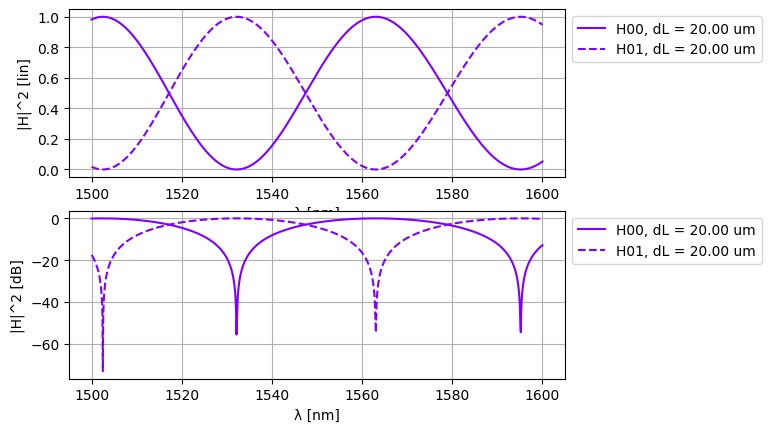

In [5]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([20,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(H00) ** 2, 1e-20))
    H01_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(H01) ** 2, 1e-20))

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section, with minor variations, for LO1a, LO1b, LO2, and LO3.


### 1.2. Helper functions for the learning outcomes

The following cells use the same compact models to reproduce the lab-book cases. Wavelengths and lengths are kept in micrometers inside the simulations; printed FSR values are converted to nanometers.

In [6]:
def power_from_field(field):
    return np.asarray(jnp.abs(field) ** 2)


def power_db_from_field(field, floor=1e-20):
    return 10.0 * np.log10(np.maximum(power_from_field(field), floor))


def loss_db_cm_to_db_um(alpha_db_cm):
    return alpha_db_cm / 1e4


def fsr_nm_from_length(length_um, lambda0_um=1.55, ng=LAB1_SIN_DEEP_NG):
    return (lambda0_um**2 / (ng * length_um)) * 1e3


def length_um_from_fsr(fsr_nm, lambda0_um=1.55, ng=LAB1_SIN_DEEP_NG):
    return lambda0_um**2 / (ng * (fsr_nm * 1e-3))


def roundtrip_field_amplitude(length_um, loss_db_um):
    return 10 ** (-(loss_db_um * length_um) / 20)


def critical_coupling_from_loss(length_um, loss_db_um):
    a = roundtrip_field_amplitude(length_um, loss_db_um)
    return 1 - a**2


def extinction_ratio_db(field):
    p = np.maximum(power_from_field(field), 1e-20)
    return 10.0 * np.log10(np.max(p) / np.min(p))


def visibility(field):
    p = power_from_field(field)
    return (np.max(p) - np.min(p)) / (np.max(p) + np.min(p))


def estimate_notch_fsr_nm(wl_um, field, min_distance_nm=4.0, prominence_fraction=0.02):
    wl_np = np.asarray(wl_um, dtype=float)
    p = power_from_field(field)
    if np.ptp(p) < 1e-10:
        return np.array([]), np.nan

    step_nm = np.median(np.diff(wl_np)) * 1e3
    distance = max(1, int(min_distance_nm / step_nm))
    prominence = max(1e-10, prominence_fraction * np.ptp(p))
    notch_idx, _ = find_peaks(-p, distance=distance, prominence=prominence)
    notch_wl_nm = wl_np[notch_idx] * 1e3
    if len(notch_wl_nm) < 2:
        return notch_wl_nm, np.nan
    return notch_wl_nm, float(np.mean(np.diff(notch_wl_nm)))


def simulate_mzi(
    wl,
    delta_l_um,
    l_base_um=10.0,
    kin=0.5,
    kout=0.5,
    wg_params=None,
    loss_db_um=0.0,
):
    wg_params = dict(wg_params or {})
    wvg_s = {**wg_params, "length": l_base_um, "loss": loss_db_um}
    wvg_n = {**wg_params, "length": l_base_um + delta_l_um, "loss": loss_db_um}
    return mzi(
        wl=wl,
        wvg_S=wvg_s,
        wvg_N=wvg_n,
        coup_E={"coupling": kin},
        coup_W={"coupling": kout},
    )


def simulate_ring_ap(wl, perimeter_um, coupling=0.5, loss_db_um=0.0, wg_params=None):
    wg_params = dict(wg_params or {})
    return ring_ap(
        wl=wl,
        wvg_ring={**wg_params, "length": perimeter_um, "loss": loss_db_um},
        coup={"coupling": coupling},
    )


def plot_transfer_functions(wl, traces, title, linear_ylim=None, db_ylim=(-80, 5)):
    wl_nm = np.asarray(wl) * 1e3
    fig, ax = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True)
    for label, field, style in traces:
        ax[0].plot(wl_nm, power_from_field(field), style, label=label)
        ax[1].plot(wl_nm, power_db_from_field(field), style, label=label)

    ax[0].set_ylabel("|H|^2 [lin]")
    ax[1].set_ylabel("|H|^2 [dB]")
    ax[1].set_xlabel("lambda [nm]")
    if linear_ylim is not None:
        ax[0].set_ylim(linear_ylim)
    if db_ylim is not None:
        ax[1].set_ylim(db_ylim)
    for axis in ax:
        axis.grid(True)
        axis.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.80, 0.96])
    return fig, ax


### LO.1a. Perfectly balanced MZI

Lab-book case: wavelength range 1500-1600 nm with 0.001 nm step, equal arm lengths, and 50/50 input and output couplers.

LO1a numeric check
out0 power range: 0.000e+00 to 6.933e-33
out1 power range: 1.000000 to 1.000000
With equal optical paths there is no wavelength-dependent fringe pattern; the output state is constant.


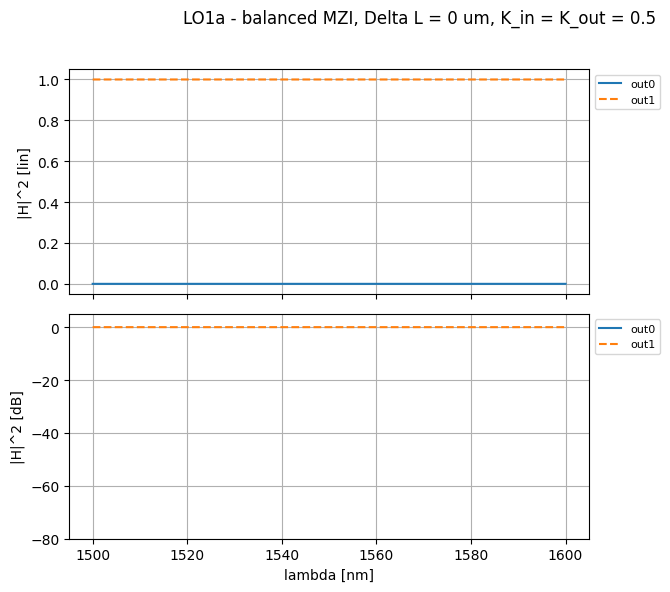

In [7]:
wl_lo1 = jnp.linspace(1.50, 1.60, 100001)

mzi_lo1a = simulate_mzi(wl_lo1, delta_l_um=0.0, kin=0.5, kout=0.5)
H00_lo1a = mzi_lo1a["in0", "out0"]
H01_lo1a = mzi_lo1a["in0", "out1"]

plot_transfer_functions(
    wl_lo1,
    [
        ("out0", H00_lo1a, "-"),
        ("out1", H01_lo1a, "--"),
    ],
    "LO1a - balanced MZI, Delta L = 0 um, K_in = K_out = 0.5",
    linear_ylim=(-0.05, 1.05),
)

print("LO1a numeric check")
print(f"out0 power range: {power_from_field(H00_lo1a).min():.3e} to {power_from_field(H00_lo1a).max():.3e}")
print(f"out1 power range: {power_from_field(H01_lo1a).min():.6f} to {power_from_field(H01_lo1a).max():.6f}")
print("With equal optical paths there is no wavelength-dependent fringe pattern; the output state is constant.")


### LO.1b. Unbalanced MZI

Lab-book case: same wavelength sweep, $\Delta L = 100~\mu\mathrm{m}$, and 50/50 input and output couplers. The expected FSR is:

$$
\Delta\lambda_\mathrm{FSR} =
\frac{\lambda_0^2}{n_g\,\Delta L}.
$$


LO1b FSR check
Theoretical FSR at 1550 nm: 12.384 nm
Estimated FSR from adjacent notches: 12.402 nm
First notches [nm]: [1508.339 1520.159 1532.164 1544.361 1556.754]
The two outputs are complementary because the ideal MZI is lossless and both couplers are balanced.


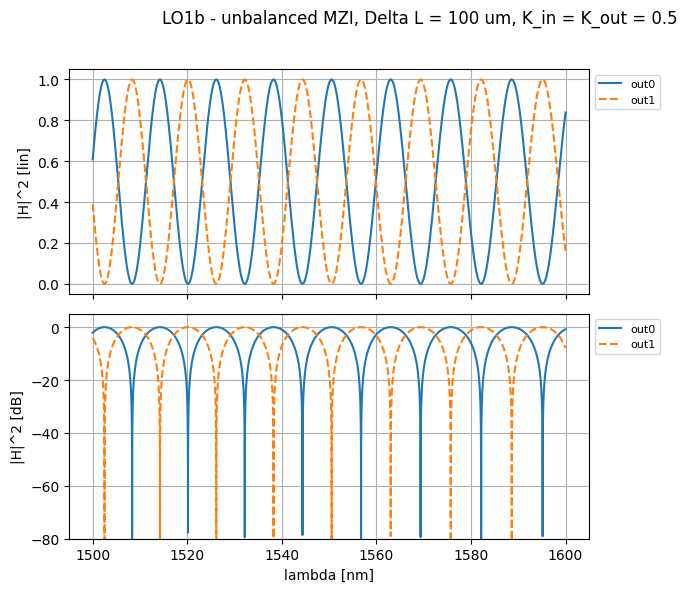

In [8]:
delta_l_lo1b_um = 100.0
mzi_lo1b = simulate_mzi(wl_lo1, delta_l_um=delta_l_lo1b_um, kin=0.5, kout=0.5)
H00_lo1b = mzi_lo1b["in0", "out0"]
H01_lo1b = mzi_lo1b["in0", "out1"]

notches_lo1b_nm, fsr_lo1b_est_nm = estimate_notch_fsr_nm(wl_lo1, H00_lo1b, min_distance_nm=6.0)
fsr_lo1b_theory_nm = fsr_nm_from_length(delta_l_lo1b_um)

plot_transfer_functions(
    wl_lo1,
    [
        ("out0", H00_lo1b, "-"),
        ("out1", H01_lo1b, "--"),
    ],
    "LO1b - unbalanced MZI, Delta L = 100 um, K_in = K_out = 0.5",
    linear_ylim=(-0.05, 1.05),
)

print("LO1b FSR check")
print(f"Theoretical FSR at 1550 nm: {fsr_lo1b_theory_nm:.3f} nm")
print(f"Estimated FSR from adjacent notches: {fsr_lo1b_est_nm:.3f} nm")
print(f"First notches [nm]: {np.array2string(notches_lo1b_nm[:5], precision=3)}")
print("The two outputs are complementary because the ideal MZI is lossless and both couplers are balanced.")


## LO.2. MZI design for FSR = 10 nm

The lab-book title asks for an MZI with FSR = 10 nm at 1550 nm. Using the same SiN group index, the required arm-length imbalance is:

$$
\Delta L =
\frac{\lambda_0^2}{n_g\,\Delta\lambda_\mathrm{FSR}}.
$$


LO2 design
Target FSR: 10.000 nm
Required Delta L: 123.841 um
Estimated FSR from the simulated notches: 9.973 nm
First notches [nm]: [1503.711 1513.182 1522.772 1532.486 1542.324 1552.289]


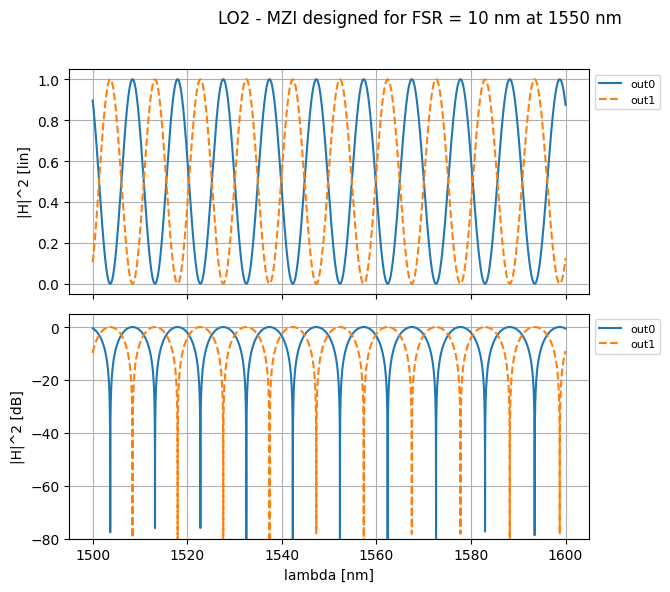

In [9]:
target_fsr_lo2_nm = 10.0
lambda0_lo2_um = 1.55
delta_l_lo2_um = length_um_from_fsr(target_fsr_lo2_nm, lambda0_um=lambda0_lo2_um)

mzi_lo2 = simulate_mzi(wl_lo1, delta_l_um=delta_l_lo2_um, kin=0.5, kout=0.5)
H00_lo2 = mzi_lo2["in0", "out0"]
H01_lo2 = mzi_lo2["in0", "out1"]
notches_lo2_nm, fsr_lo2_est_nm = estimate_notch_fsr_nm(wl_lo1, H00_lo2, min_distance_nm=5.0)

plot_transfer_functions(
    wl_lo1,
    [
        ("out0", H00_lo2, "-"),
        ("out1", H01_lo2, "--"),
    ],
    "LO2 - MZI designed for FSR = 10 nm at 1550 nm",
    linear_ylim=(-0.05, 1.05),
)

print("LO2 design")
print(f"Target FSR: {target_fsr_lo2_nm:.3f} nm")
print(f"Required Delta L: {delta_l_lo2_um:.3f} um")
print(f"Estimated FSR from the simulated notches: {fsr_lo2_est_nm:.3f} nm")
print(f"First notches [nm]: {np.array2string(notches_lo2_nm[:6], precision=3)}")


## LO.3. Delay imbalance with loss

Lab-book case: silicon waveguide model with $n_\mathrm{eff}=2.38$, $n_g=4.25$, $D=0$, base arm length $1000~\mu\mathrm{m}$, extra imbalance $55960.0840224255~\mu\mathrm{m}$, and propagation loss 4 dB/cm. The wavelength window is 1550-1550.5 nm with 0.0005 nm step.


Case 1: K_in = 0.5, K_out = 0.5
  out0 ER = 1.32 dB, visibility = 0.151
  out1 ER = 1.32 dB, visibility = 0.151
Case 2: K_in = 0.1, K_out = 0.5
  out0 ER = 0.44 dB, visibility = 0.051
  out1 ER = 0.44 dB, visibility = 0.051
LO3 loss matching
Short-arm field attenuation: 0.954993
Long-arm field attenuation: 0.072577
Input coupling coefficient that equalizes fields at the output coupler: K_in = 0.994258
Matched out0 ER = 70.46 dB
Matched out1 ER = 60.46 dB


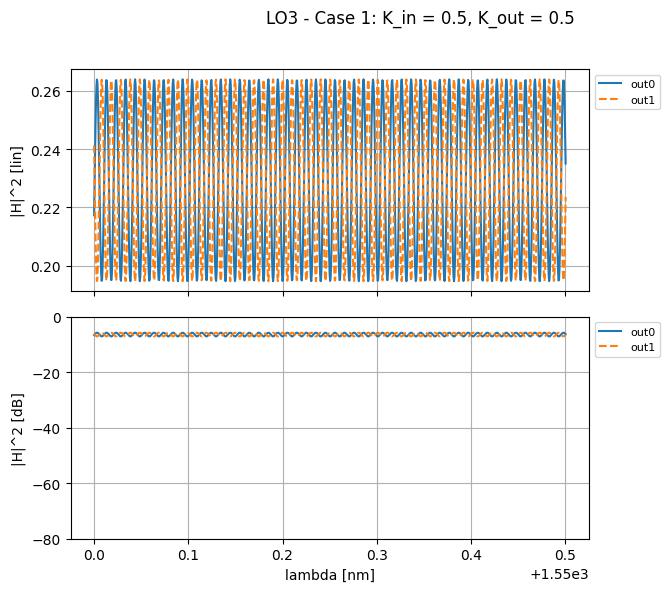

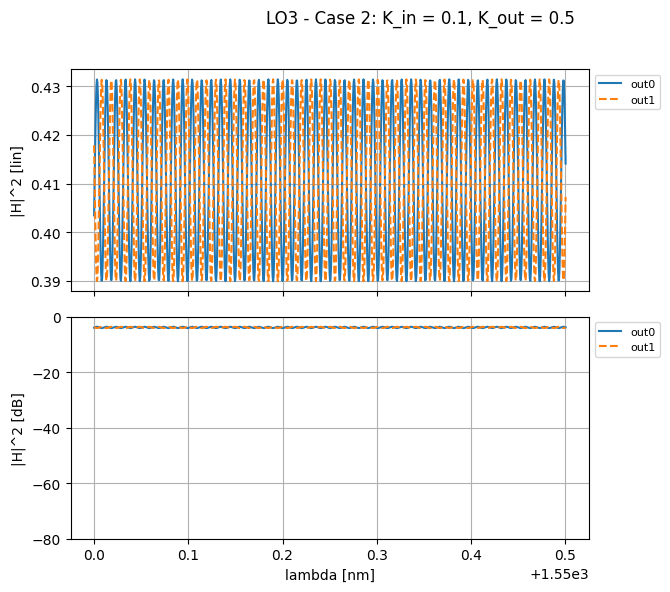

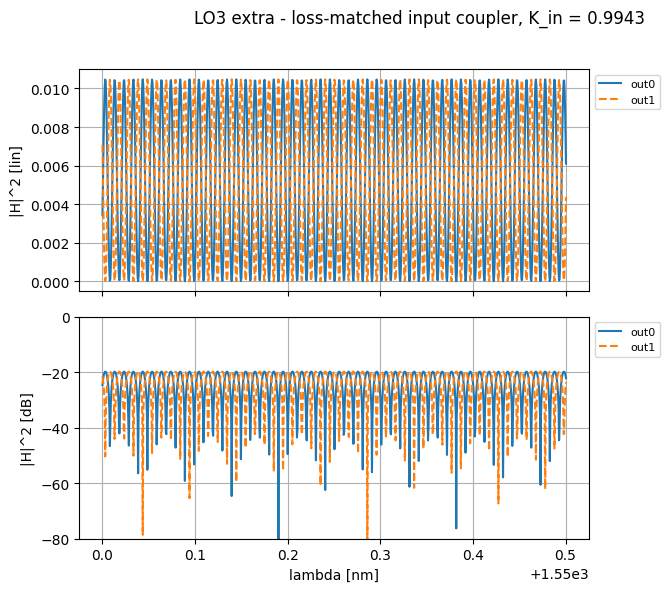

In [10]:
wl_lo3 = jnp.arange(1.550, 1.5505 + 0.5e-6, 0.5e-6)
silicon_wg = {"neff": 2.38, "ng": 4.25, "D": 0.0}
l_base_lo3_um = 1000.0
delta_l_lo3_um = 55960.0840224255
loss_lo3_db_cm = 4.0
loss_lo3_db_um = loss_db_cm_to_db_um(loss_lo3_db_cm)

cases_lo3 = [
    ("Case 1: K_in = 0.5, K_out = 0.5", 0.5, 0.5),
    ("Case 2: K_in = 0.1, K_out = 0.5", 0.1, 0.5),
]

for title, kin, kout in cases_lo3:
    sdict = simulate_mzi(
        wl_lo3,
        delta_l_um=delta_l_lo3_um,
        l_base_um=l_base_lo3_um,
        kin=kin,
        kout=kout,
        wg_params=silicon_wg,
        loss_db_um=loss_lo3_db_um,
    )
    H00 = sdict["in0", "out0"]
    H01 = sdict["in0", "out1"]
    plot_transfer_functions(
        wl_lo3,
        [("out0", H00, "-"), ("out1", H01, "--")],
        f"LO3 - {title}",
        db_ylim=(-80, 0),
    )
    print(title)
    print(f"  out0 ER = {extinction_ratio_db(H00):.2f} dB, visibility = {visibility(H00):.3f}")
    print(f"  out1 ER = {extinction_ratio_db(H01):.2f} dB, visibility = {visibility(H01):.3f}")

short_amp = roundtrip_field_amplitude(l_base_lo3_um, loss_lo3_db_um)
long_amp = roundtrip_field_amplitude(l_base_lo3_um + delta_l_lo3_um, loss_lo3_db_um)
kin_loss_matched = short_amp**2 / (short_amp**2 + long_amp**2)

mzi_lo3_matched = simulate_mzi(
    wl_lo3,
    delta_l_um=delta_l_lo3_um,
    l_base_um=l_base_lo3_um,
    kin=kin_loss_matched,
    kout=0.5,
    wg_params=silicon_wg,
    loss_db_um=loss_lo3_db_um,
)
H00_lo3_matched = mzi_lo3_matched["in0", "out0"]
H01_lo3_matched = mzi_lo3_matched["in0", "out1"]

plot_transfer_functions(
    wl_lo3,
    [("out0", H00_lo3_matched, "-"), ("out1", H01_lo3_matched, "--")],
    f"LO3 extra - loss-matched input coupler, K_in = {kin_loss_matched:.4f}",
    db_ylim=(-80, 0),
)

print("LO3 loss matching")
print(f"Short-arm field attenuation: {short_amp:.6f}")
print(f"Long-arm field attenuation: {long_amp:.6f}")
print(f"Input coupling coefficient that equalizes fields at the output coupler: K_in = {kin_loss_matched:.6f}")
print(f"Matched out0 ER = {extinction_ratio_db(H00_lo3_matched):.2f} dB")
print(f"Matched out1 ER = {extinction_ratio_db(H01_lo3_matched):.2f} dB")


**LO.3 comments.** The lossy long arm reduces fringe visibility because the two fields arriving at the second coupler have different amplitudes. Setting $K_\mathrm{in}=0.1$ sends even less power to the long arm, so the interference contrast is weaker. The loss-matched design sends almost all input power to the longer arm, recovering a high extinction ratio at the cost of insertion loss.


## LO.4. Ring Resonators


### 1.1. Ring Resonator Circuit Models

We can implement two different ring-resonator variations: a simple single-bus ring consisting of a coupler connected to a waveguide (`ring_ap`), and a double-bus ring that needs an extra coupler and the corresponding waveguides to connect both buses (`ring_2bus`):

<img src="rings.png" alt="Ring resonator circuits" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [11]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Then we can test the circuit to check that it works.


Text(0, 0.5, '|H|^2 [dB]')

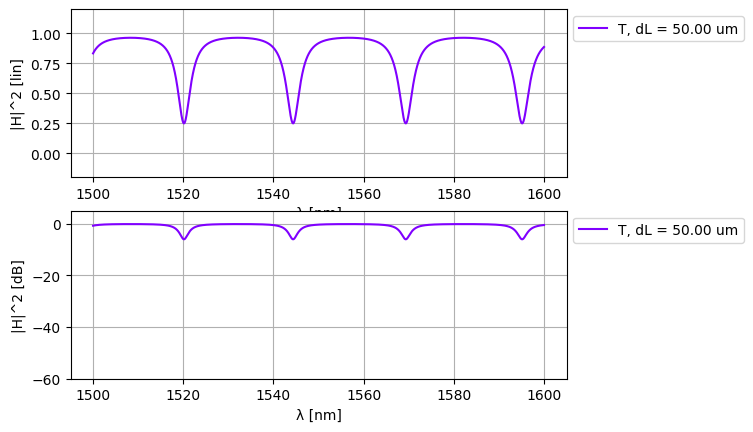

In [12]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(T) ** 2, 1e-20))

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} um")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} um")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers.


In [13]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check that it works.


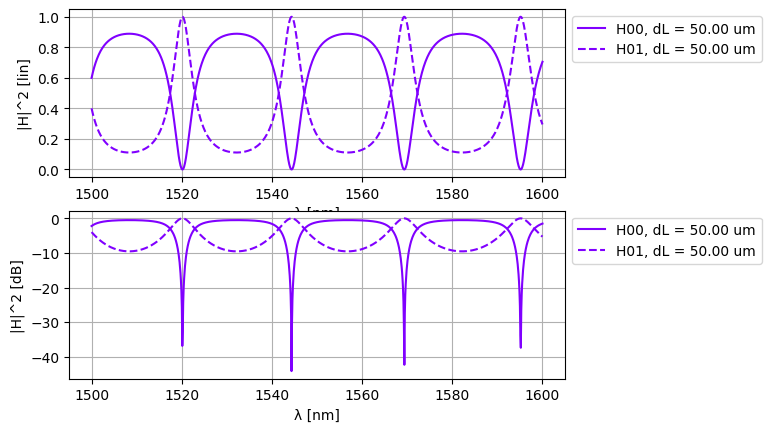

In [14]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.0})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(H00) ** 2, 1e-20))
    H01_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(H01) ** 2, 1e-20))

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]");


The resulting interference pattern again exhibits periodic behavior. In this case, the **free spectral range** (FSR) satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

where $L_r$ is the ring perimeter. In our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.


#### **HINT**

You can perform parametric variations using the code provided. For instance, the following case performs a loss sweep.


Text(0, 0.5, '|H|^2 [dB]')

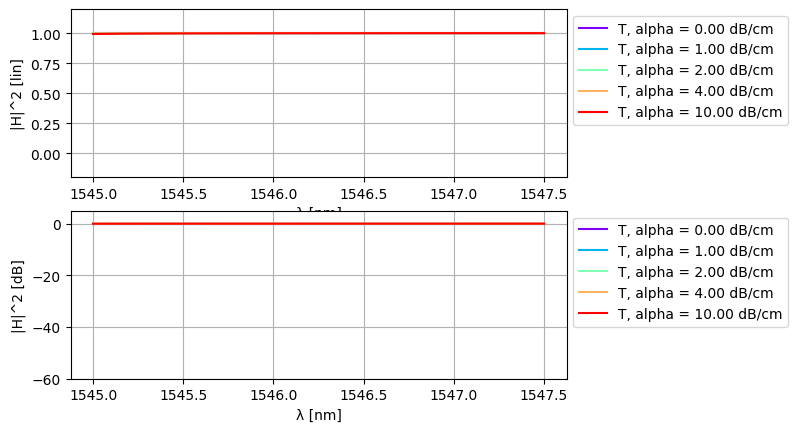

In [15]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
# Update the variable you enumerate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 10.0 * jnp.log10(jnp.maximum(jnp.abs(T) ** 2, 1e-20))

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LO4, LO5, and LO6.


## LO.4. Ring resonator: simple all-pass case

For a single-bus ring, the FSR is controlled by the ring perimeter:

$$
\Delta\lambda_\mathrm{FSR} =
\frac{\lambda_0^2}{n_g\,L_r}.
$$

The coupler coefficient is constant with wavelength in this compact model.


LO4 ring FSR
Ring perimeter: 75.000 um
Theoretical FSR at 1550 nm: 16.512 nm
Estimated FSR from adjacent resonances: 16.579 nm
Resonances [nm]: [1512.261 1528.141 1544.362 1560.928 1577.859 1595.155]
Through-port ER: 4.86 dB


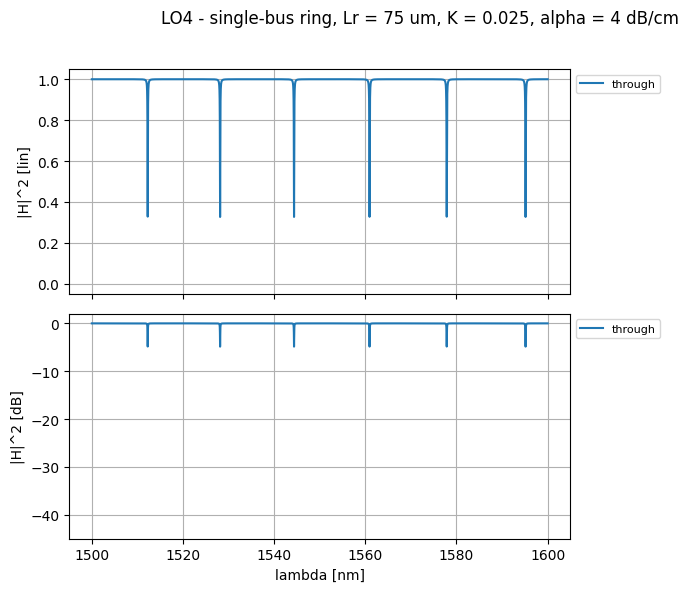

In [16]:
wl_ring = jnp.linspace(1.50, 1.60, 20000)
ring_lo4_perimeter_um = 75.0
ring_lo4_coupling = 0.025
ring_lo4_loss_db_cm = 4.0
ring_lo4_loss_db_um = loss_db_cm_to_db_um(ring_lo4_loss_db_cm)

ring_lo4 = simulate_ring_ap(
    wl_ring,
    perimeter_um=ring_lo4_perimeter_um,
    coupling=ring_lo4_coupling,
    loss_db_um=ring_lo4_loss_db_um,
)
T_lo4 = ring_lo4["in0", "out0"]
notches_lo4_nm, fsr_lo4_est_nm = estimate_notch_fsr_nm(wl_ring, T_lo4, min_distance_nm=8.0)
fsr_lo4_theory_nm = fsr_nm_from_length(ring_lo4_perimeter_um)

plot_transfer_functions(
    wl_ring,
    [("through", T_lo4, "-")],
    "LO4 - single-bus ring, Lr = 75 um, K = 0.025, alpha = 4 dB/cm",
    linear_ylim=(-0.05, 1.05),
    db_ylim=(-45, 2),
)

print("LO4 ring FSR")
print(f"Ring perimeter: {ring_lo4_perimeter_um:.3f} um")
print(f"Theoretical FSR at 1550 nm: {fsr_lo4_theory_nm:.3f} nm")
print(f"Estimated FSR from adjacent resonances: {fsr_lo4_est_nm:.3f} nm")
print(f"Resonances [nm]: {np.array2string(notches_lo4_nm[:6], precision=3)}")
print(f"Through-port ER: {extinction_ratio_db(T_lo4):.2f} dB")


**LO.4 comments.** The resonances repeat periodically in wavelength. Increasing the perimeter increases the round-trip delay and therefore decreases the FSR; reducing the perimeter has the opposite effect.

## LO.5. Ring resonator design for FSR = 15 nm

The required perimeter follows directly from the FSR equation. Critical coupling for the all-pass ring is reached when the coupler power coefficient equals the round-trip power loss:

$$
K_\mathrm{crit}=1-a^2, \qquad a=10^{-\alpha L_r/20}.
$$

Here, $\alpha$ is the propagation loss in dB/um and $L_r$ is the ring perimeter in um.


LO5 ring design
Target FSR: 15.000 nm
Designed perimeter: 82.561 um
Theoretical FSR: 15.000 nm
Loss: 4.0 dB/cm (4.00e-04 dB/um)
Critical coupling coefficient: Kcrit = 0.00758

K sweep around the design resonance
K        ER [dB]    min |T|^2    classification


0.00300       7.20   1.9044e-01   undercoupled
0.00758      28.32   1.4718e-03   near critical
0.01000      16.93   2.0271e-02   overcoupled
0.02500       5.38   2.8972e-01   overcoupled
0.10000       1.26   7.4883e-01   overcoupled


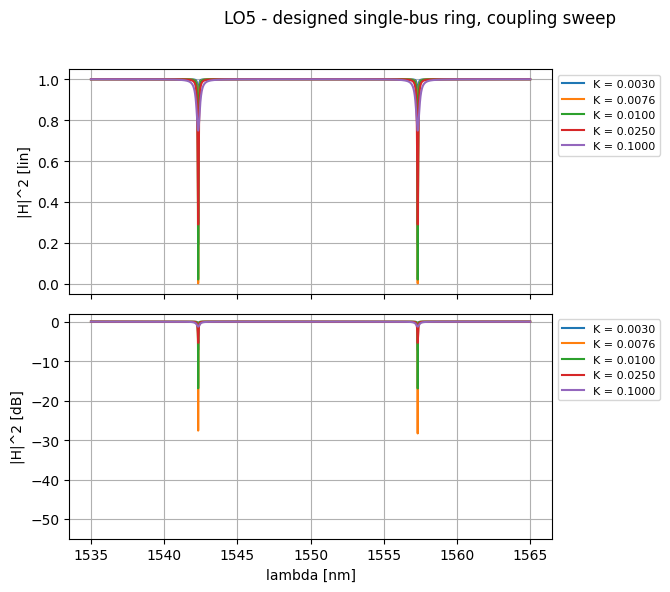

In [17]:
target_ring_fsr_nm = 15.0
ring_lo5_perimeter_um = length_um_from_fsr(target_ring_fsr_nm)
ring_lo5_loss_db_cm = 4.0
ring_lo5_loss_db_um = loss_db_cm_to_db_um(ring_lo5_loss_db_cm)
ring_lo5_kcrit = critical_coupling_from_loss(ring_lo5_perimeter_um, ring_lo5_loss_db_um)

wl_ring_design = jnp.linspace(1.535, 1.565, 12000)
ring_lo5_couplings = np.array([0.003, ring_lo5_kcrit, 0.01, 0.025, 0.1])
traces_lo5 = []

print("LO5 ring design")
print(f"Target FSR: {target_ring_fsr_nm:.3f} nm")
print(f"Designed perimeter: {ring_lo5_perimeter_um:.3f} um")
print(f"Theoretical FSR: {fsr_nm_from_length(ring_lo5_perimeter_um):.3f} nm")
print(f"Loss: {ring_lo5_loss_db_cm:.1f} dB/cm ({ring_lo5_loss_db_um:.2e} dB/um)")
print(f"Critical coupling coefficient: Kcrit = {ring_lo5_kcrit:.5f}")
print()
print("K sweep around the design resonance")
print("K        ER [dB]    min |T|^2    classification")

for k in ring_lo5_couplings:
    ring_case = simulate_ring_ap(
        wl_ring_design,
        perimeter_um=ring_lo5_perimeter_um,
        coupling=float(k),
        loss_db_um=ring_lo5_loss_db_um,
    )
    T = ring_case["in0", "out0"]
    pwr = power_from_field(T)
    if k < 0.8 * ring_lo5_kcrit:
        classification = "undercoupled"
    elif k > 1.25 * ring_lo5_kcrit:
        classification = "overcoupled"
    else:
        classification = "near critical"
    print(f"{k:0.5f}   {extinction_ratio_db(T):8.2f}   {pwr.min():10.4e}   {classification}")
    traces_lo5.append((f"K = {k:.4f}", T, "-"))

plot_transfer_functions(
    wl_ring_design,
    traces_lo5,
    "LO5 - designed single-bus ring, coupling sweep",
    linear_ylim=(-0.05, 1.05),
    db_ylim=(-55, 2),
);


**LO.5 comments.** The designed perimeter gives a simulated FSR close to 15 nm. Critical coupling is obtained by setting the coupling coefficient approximately equal to $K_\mathrm{crit}$; at that point, the through-port resonance has the deepest notch and the largest extinction ratio.


## LO.6a. Effect of coupling coefficient K

The lab-book sweep changes $K$ from 0.1 to 0.9 in steps of 0.1. The perimeter is the LO.5 design and the loss is kept at 4 dB/cm.

LO6a - effect of K
Reference Kcrit for this ring and loss: 0.00758
K      ER [dB]   min |T|^2    classification
0.1       1.26   7.4883e-01   overcoupled
0.2       0.59   8.7240e-01   overcoupled
0.3       0.37   9.1804e-01   overcoupled
0.4       0.26   9.4189e-01   overcoupled
0.5       0.19   9.5665e-01   overcoupled
0.6       0.14   9.6679e-01   overcoupled
0.7       0.10   9.7431e-01   overcoupled
0.8       0.07   9.8029e-01   overcoupled
0.9       0.05   9.8547e-01   overcoupled


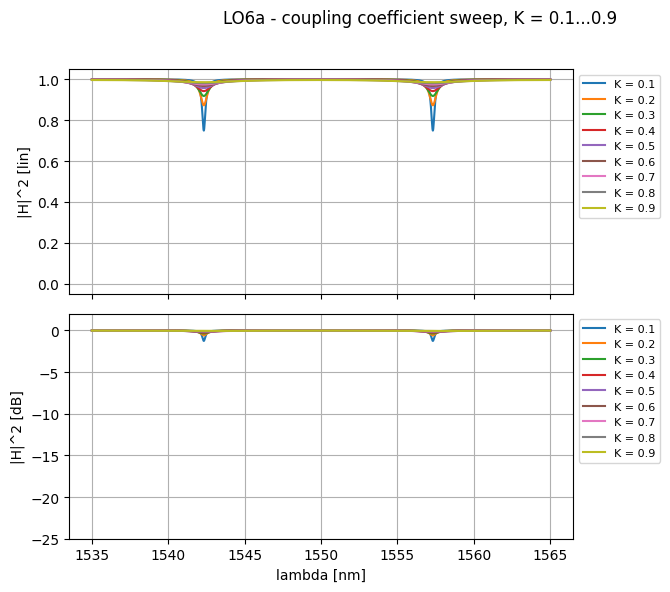

In [18]:
lo6a_k_values = np.arange(0.1, 1.0, 0.1)
traces_lo6a = []
print("LO6a - effect of K")
print(f"Reference Kcrit for this ring and loss: {ring_lo5_kcrit:.5f}")
print("K      ER [dB]   min |T|^2    classification")

for k in lo6a_k_values:
    ring_case = simulate_ring_ap(
        wl_ring_design,
        perimeter_um=ring_lo5_perimeter_um,
        coupling=float(k),
        loss_db_um=ring_lo5_loss_db_um,
    )
    T = ring_case["in0", "out0"]
    pwr = power_from_field(T)
    classification = "overcoupled" if k > ring_lo5_kcrit else "undercoupled"
    print(f"{k:0.1f}    {extinction_ratio_db(T):7.2f}   {pwr.min():10.4e}   {classification}")
    traces_lo6a.append((f"K = {k:.1f}", T, "-"))

plot_transfer_functions(
    wl_ring_design,
    traces_lo6a,
    "LO6a - coupling coefficient sweep, K = 0.1...0.9",
    linear_ylim=(-0.05, 1.05),
    db_ylim=(-25, 2),
);


**LO.6a comments.** For 4 dB/cm loss, the critical coefficient is much smaller than 0.1, so all requested cases are overcoupled. The resonance notch becomes shallower as $K$ moves farther away from $K_\mathrm{crit}$.


## LO.6b. Effect of propagation loss

The lab-book sweep changes propagation loss from 0 to 8 dB/cm in steps of 1 dB/cm. A fixed $K=0.01$ is used so that the sweep crosses near the critical-coupling condition.

LO6b - effect of propagation loss
Fixed K: 0.010
alpha [dB/cm]   Kcrit     ER [dB]   min |T|^2    classification
   0.0        0.00000      0.00   1.0000e+00   overcoupled
   1.0        0.00190      3.31   4.6622e-01   overcoupled
   2.0        0.00379      6.89   2.0487e-01   overcoupled
   3.0        0.00569     11.11   7.7419e-02   overcoupled
   4.0        0.00758     16.93   2.0271e-02   overcoupled
   5.0        0.00946     27.78   1.6673e-03   near critical
   6.0        0.01134     23.25   4.7299e-03   near critical
   7.0        0.01322     16.98   2.0054e-02   undercoupled


   8.0        0.01509     13.75   4.2210e-02   undercoupled


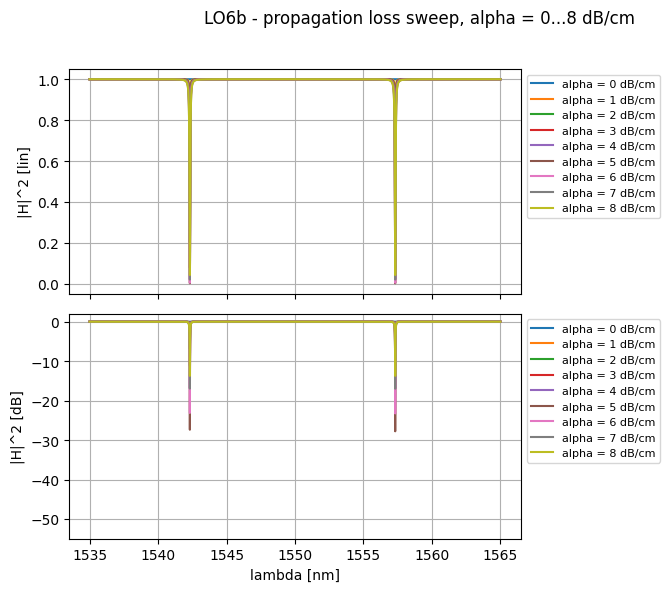

In [19]:
lo6b_loss_values_db_cm = np.arange(0, 9, 1)
lo6b_fixed_k = 0.01
traces_lo6b = []
print("LO6b - effect of propagation loss")
print(f"Fixed K: {lo6b_fixed_k:.3f}")
print("alpha [dB/cm]   Kcrit     ER [dB]   min |T|^2    classification")

for alpha_db_cm in lo6b_loss_values_db_cm:
    alpha_db_um = loss_db_cm_to_db_um(alpha_db_cm)
    kcrit = critical_coupling_from_loss(ring_lo5_perimeter_um, alpha_db_um)
    ring_case = simulate_ring_ap(
        wl_ring_design,
        perimeter_um=ring_lo5_perimeter_um,
        coupling=lo6b_fixed_k,
        loss_db_um=alpha_db_um,
    )
    T = ring_case["in0", "out0"]
    pwr = power_from_field(T)
    if lo6b_fixed_k < 0.8 * kcrit:
        classification = "undercoupled"
    elif lo6b_fixed_k > 1.25 * kcrit:
        classification = "overcoupled"
    else:
        classification = "near critical"
    print(f"{alpha_db_cm:6.1f}        {kcrit:0.5f}   {extinction_ratio_db(T):7.2f}   {pwr.min():10.4e}   {classification}")
    traces_lo6b.append((f"alpha = {alpha_db_cm:.0f} dB/cm", T, "-"))

plot_transfer_functions(
    wl_ring_design,
    traces_lo6b,
    "LO6b - propagation loss sweep, alpha = 0...8 dB/cm",
    linear_ylim=(-0.05, 1.05),
    db_ylim=(-55, 2),
);


**LO.6b comments.** With $K=0.01$, the low-loss cases are overcoupled because the ring does not lose enough power per round trip. As loss increases, $K_\mathrm{crit}$ approaches the fixed coupling value; the resonance closest to critical coupling gives the largest extinction ratio.
